# 01 · Data quality of the charging archive

**Question this notebook answers:** which part of the archive is trustworthy enough to train models on, and which stations should those models use?

It reads the daily Parquet files written by `python -m evops.ingest` and produces three files the later phases use:

| Output | Used for |
|---|---|
| `data/processed/daily_summary.parquet` | dashboard history charts |
| `data/processed/model_window.json` | which days the models train and test on |
| `data/processed/station_panel.parquet` | the fixed set of stations the models use |

Run it with **Run All**. It takes 2–4 minutes on the full archive, using only pandas and pyarrow.

In [1]:
import json
import time
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

# Repo root, whether the notebook runs from notebooks/ or from the repo root
ROOT = Path.cwd() if (Path.cwd() / "evops").exists() else Path.cwd().parent
PROCESSED = ROOT / "data" / "processed"
FILES = sorted((PROCESSED / "status").glob("date=*.parquet"))
print(f"{len(FILES)} daily files in {PROCESSED / 'status'}")

248 daily files in C:\Projects\EV_charging\ev-charging-ops\ev-charging-ops\data\processed\status


### One pass over the archive

The full archive has a few hundred million rows, too many to load at once. So each day's file is read on its own, summarised, and dropped. Everything below works from these small summaries. Takes 2–4 minutes.

In [2]:
LIVE = ["available", "charging", "reserved", "out_of_order", "inoperative", "unknown"]
COLS = ["station_id", "source", *LIVE, "static", "outdated"]

def day_of(path):
    return pd.Timestamp(path.stem.split("=")[1])

daily_rows, source_rows = [], []
t0 = time.time()
for i, path in enumerate(FILES, 1):
    df = pd.read_parquet(path, columns=COLS)
    df["source"] = df["source"].astype(str)
    df["occupied"] = df["charging"] + df["reserved"]
    df["out_of_service"] = df["out_of_order"] + df["inoperative"]
    df["live"] = df[LIVE].sum(axis=1)

    # Average each station over the day's records, then add stations up
    station_day = df.groupby("station_id")[["available", "occupied", "out_of_service", "unknown", "static"]].mean()
    daily_rows.append({"day": day_of(path), "stations": len(station_day), **station_day.sum().to_dict()})

    per_source = df.groupby("source").agg(
        stations=("station_id", "nunique"), unknown=("unknown", "sum"), live=("live", "sum"),
        outdated_true=("outdated", "sum"), outdated_n=("outdated", "count"),
    ).reset_index()
    per_source["day"] = day_of(path)
    source_rows.append(per_source)
    if i % 25 == 0 or i == len(FILES):
        print(f"  {i}/{len(FILES)} days summarised ({time.time() - t0:.0f}s)")

daily = pd.DataFrame(daily_rows)
by_source = pd.concat(source_rows, ignore_index=True)

  25/248 days summarised (2s)


  50/248 days summarised (4s)


  75/248 days summarised (15s)


  100/248 days summarised (26s)


  125/248 days summarised (51s)


  150/248 days summarised (79s)


  175/248 days summarised (107s)


  200/248 days summarised (133s)


  225/248 days summarised (136s)


  248/248 days summarised (141s)


In [3]:
# Chart style: thin marks, recessive grid, text in ink colours, never series colours
INK, INK_2, GRID, SURFACE, BAND = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb", "#f0efec"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "lines.linewidth": 2, "font.size": 10, "figure.dpi": 110,
})

def month_axis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

## 1 · How coverage and capture frequency changed

Two different things changed over the archive's life: **how many stations** it covers, and **how often** each station is recorded. They are drawn as two panels on a shared time axis, because they have different units.

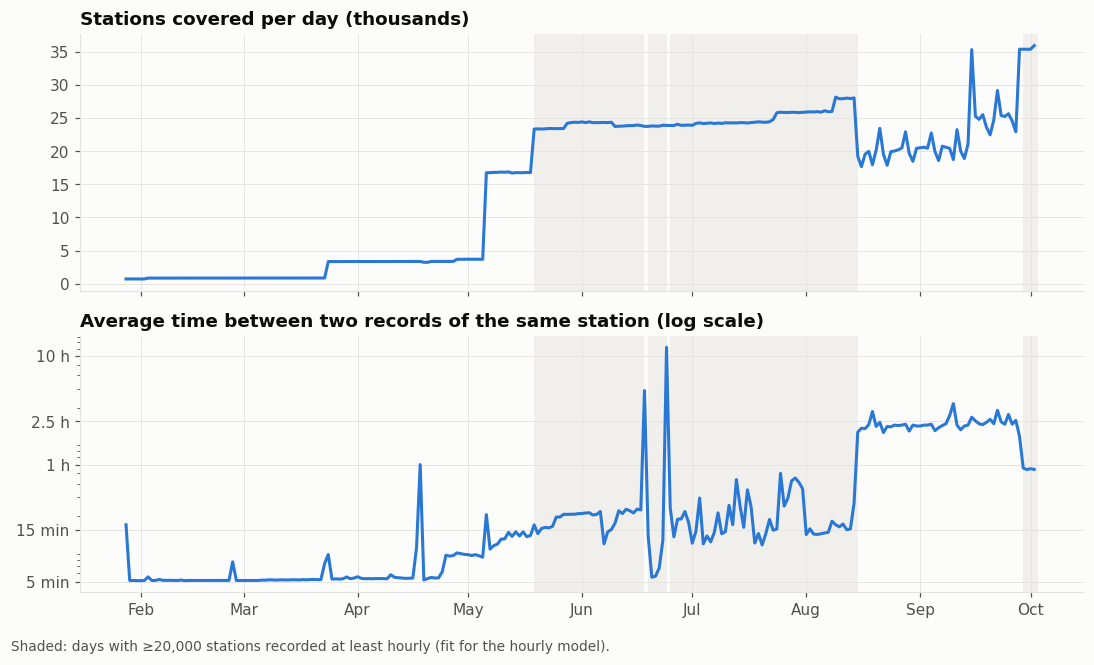

In [4]:
manifest = pd.read_csv(PROCESSED / "manifest.csv", parse_dates=["day"]).sort_values("day")
manifest["minutes_between"] = 1440 / manifest["snapshots_per_station"]

# Days fit for an hourly model: Germany-wide coverage AND at least hourly capture
MIN_STATIONS, MIN_SNAPSHOTS = 20_000, 24
manifest["fit_for_model"] = (manifest["stations"] >= MIN_STATIONS) & (
    manifest["snapshots_per_station"] >= MIN_SNAPSHOTS
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(manifest["day"], manifest["stations"] / 1000, color=SERIES[0])
ax1.set_title("Stations covered per day (thousands)")
ax2.plot(manifest["day"], manifest["minutes_between"], color=SERIES[0])
ax2.set_yscale("log")
ax2.set_yticks([5, 15, 60, 150, 600])
ax2.set_yticklabels(["5 min", "15 min", "1 h", "2.5 h", "10 h"])
ax2.set_title("Average time between two records of the same station (log scale)")
for ax in (ax1, ax2):
    for day in manifest.loc[manifest["fit_for_model"], "day"]:
        ax.axvspan(day, day + pd.Timedelta(days=1), color=BAND, lw=0, zorder=0)
month_axis(ax2)
fig.text(0.01, 0.005, "Shaded: days with ≥20,000 stations recorded at least hourly (fit for the hourly model).",
         color=INK_2, fontsize=9)
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## 2 · When each operator joined the feed

A network-wide total over time mixes real change with operators joining or leaving. This shows when each source appears, one small panel per source so no colour key is needed.

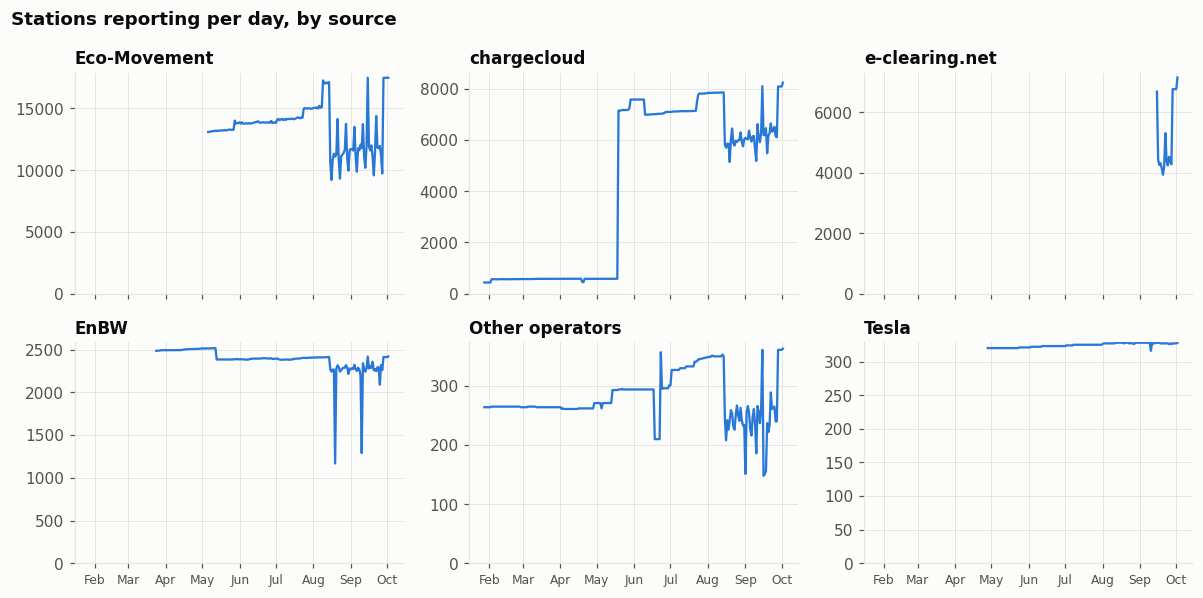

,first day with ≥50 stations,stations on last day
group,,
Other operators,2026-01-28,363
chargecloud,2026-01-28,8236
EnBW,2026-03-24,2421
Tesla,2026-04-28,328
Eco-Movement,2026-05-06,17477
e-clearing.net,2026-09-15,7155


In [5]:
SOURCE_GROUPS = {
    "datex2_ecomovement": "Eco-Movement", "datex2_chargecloud": "chargecloud",
    "chargecloud_stuttgart": "chargecloud", "chargecloud_ludwigsburg": "chargecloud",
    "chargecloud_pforzheim": "chargecloud", "chargecloud_tuebingen": "chargecloud",
    "datex2_e_clearing_net": "e-clearing.net", "datex2_enbw": "EnBW", "datex2_tesla": "Tesla",
}
by_source["group"] = by_source["source"].map(SOURCE_GROUPS).fillna("Other operators")
grouped = by_source.groupby(["day", "group"], as_index=False)["stations"].sum()

order = (grouped[grouped["day"] == grouped["day"].max()]
         .sort_values("stations", ascending=False)["group"].tolist())
order += [g for g in grouped["group"].unique() if g not in order]

fig, axes = plt.subplots(2, 3, figsize=(11, 5.5), sharex=True)
for ax, group in zip(axes.flat, order):
    g = grouped[grouped["group"] == group]
    ax.plot(g["day"], g["stations"], color=SERIES[0], lw=1.5)
    ax.set_title(group, fontsize=11)
    ax.set_ylim(bottom=0)
    month_axis(ax)
    ax.tick_params(axis="x", labelsize=8)
for ax in list(axes.flat)[len(order):]:
    ax.set_visible(False)
fig.suptitle("Stations reporting per day, by source", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
plt.show()

joins = (grouped[grouped["stations"] >= 50].groupby("group")["day"].min()
         .rename("first day with ≥50 stations").dt.date.to_frame())
joins["stations on last day"] = grouped[grouped["day"] == grouped["day"].max()].set_index("group")["stations"]
joins.sort_values("first day with ≥50 stations")

## 3 · What state the charge points are in

For each station and day, the counts are averaged over that day's records, then summed across stations. "Static" charge points (no live status) are left out, so the four shares add up to 100%.

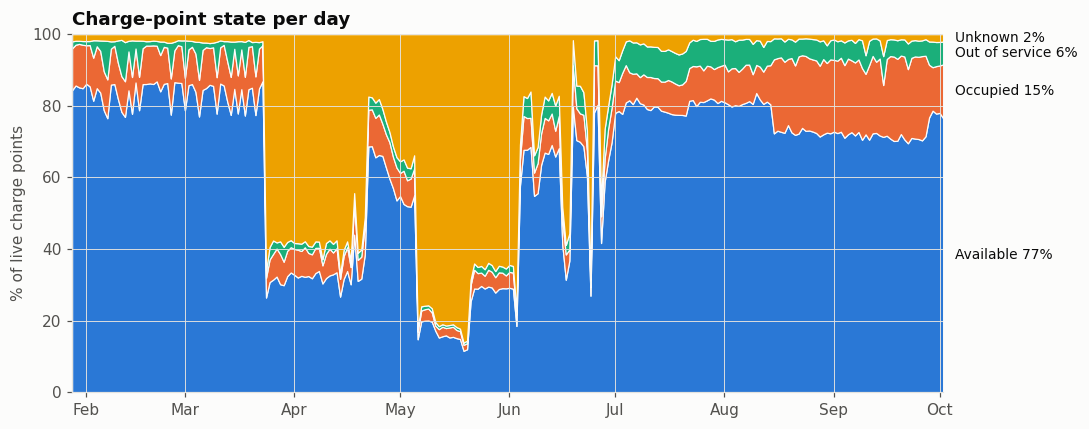

In [6]:
STATES = ["available", "occupied", "out_of_service", "unknown"]
LABELS = {"available": "Available", "occupied": "Occupied", "out_of_service": "Out of service", "unknown": "Unknown"}
daily["live_points"] = daily[STATES].sum(axis=1)
for s in STATES:
    daily[f"share_{s}"] = daily[s] / daily["live_points"]
daily.to_parquet(PROCESSED / "daily_summary.parquet", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
shares = [daily[f"share_{s}"] * 100 for s in STATES]
ax.stackplot(daily["day"], shares, colors=SERIES[:4], edgecolor=SURFACE, linewidth=0.8)
ax.set_ylim(0, 100)
ax.set_ylabel("% of live charge points")
ax.set_title("Charge-point state per day")
last = daily.iloc[-1]
y = 0
for s, colour in zip(STATES, SERIES):
    share = last[f"share_{s}"] * 100
    ax.annotate(f"{LABELS[s]} {share:.0f}%", xy=(last["day"], y + share / 2),
                xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, color=INK)
    y += share
month_axis(ax)
ax.margins(x=0)
fig.tight_layout()
plt.show()

## 4 · Which operators report "unknown", and since when

An "unknown" connector is a data gap, not a broken charger. The monthly table shows when each operator's live status became usable; the bar chart shows the current feed (last 7 days).

In [7]:
monthly_unknown = (by_source.assign(month=by_source["day"].dt.strftime("%Y-%m"))
                   .groupby(["month", "source"], as_index=False)[["unknown", "live"]].sum())
monthly_unknown["unknown_pct"] = 100 * monthly_unknown["unknown"] / monthly_unknown["live"].where(monthly_unknown["live"] > 0)
major = by_source.groupby("source")["stations"].max().loc[lambda s: s >= 300].index
(monthly_unknown[monthly_unknown["source"].isin(major)]
 .pivot(index="source", columns="month", values="unknown_pct").round(0)
 .style.format("{:.0f}%", na_rep="").background_gradient(cmap="Blues", axis=None)
 .set_caption("% of live charge-point readings with status 'unknown', by month"))

month,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09,2026-10
source,,,,,,,,
datex2_chargecloud,,,24%,14%,0%,0%,0%,0%
datex2_e_clearing_net,,,,,,,5%,4%
datex2_ecomovement,,,100%,27%,5%,3%,2%,3%
datex2_enbw,75%,62%,21%,21%,0%,0%,0%,0%
datex2_tesla,,75%,82%,60%,10%,2%,3%,2%


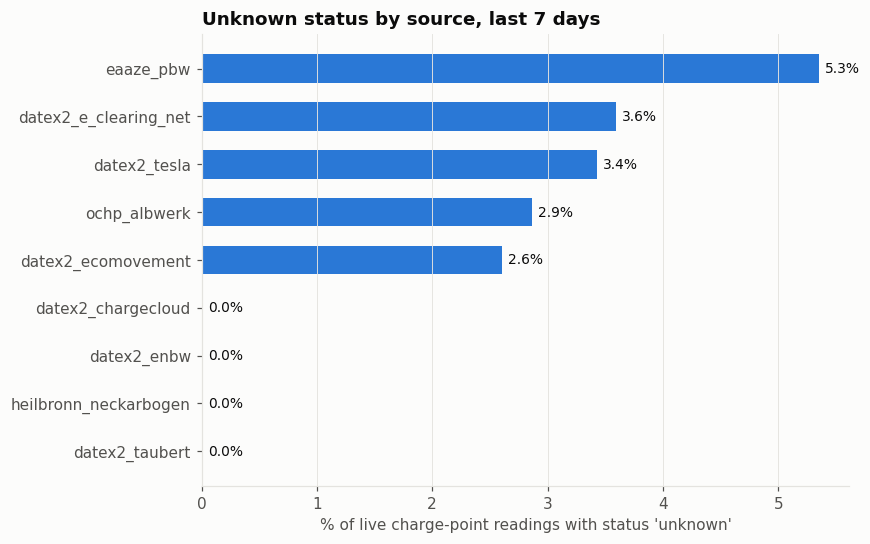

,source,unknown_share,outdated_share,stations
0,datex2_taubert,0.0,14.4,125
1,heilbronn_neckarbogen,0.0,0.0,24
2,datex2_enbw,0.0,1.2,2421
3,datex2_chargecloud,0.0,7.4,8236
4,datex2_ecomovement,2.6,17.2,17477
5,ochp_albwerk,2.9,1.3,123
6,datex2_tesla,3.4,0.0,328
7,datex2_e_clearing_net,3.6,8.5,7155
8,eaaze_pbw,5.3,16.0,82


In [8]:
last7 = by_source[by_source["day"] > by_source["day"].max() - pd.Timedelta(days=7)]
recent = last7.groupby("source").agg(
    unknown=("unknown", "sum"), live=("live", "sum"),
    outdated_true=("outdated_true", "sum"), outdated_n=("outdated_n", "sum"), stations=("stations", "max"),
)
recent = recent[recent["stations"] >= 20]
recent = pd.DataFrame({
    "source": recent.index,
    "unknown_share": (recent["unknown"] / recent["live"].where(recent["live"] > 0)).values,
    "outdated_share": (recent["outdated_true"] / recent["outdated_n"].where(recent["outdated_n"] > 0)).values,
    "stations": recent["stations"].values,
}).sort_values("unknown_share").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 0.45 * len(recent) + 1))
ax.barh(recent["source"], recent["unknown_share"] * 100, color=SERIES[0], height=0.6)
for i, v in enumerate(recent["unknown_share"] * 100):
    ax.annotate(f"{v:.1f}%", xy=(v, i), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK)
ax.set_xlabel("% of live charge-point readings with status 'unknown'")
ax.set_title("Unknown status by source, last 7 days")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()
recent.assign(unknown_share=lambda d: (d.unknown_share * 100).round(1),
              outdated_share=lambda d: (d.outdated_share * 100).round(1))

## 5 · Choose the modelling window

A day is fit for the hourly model when all three hold:

1. Germany-wide coverage (≥ 20,000 stations),
2. at least hourly capture (≥ 24 records per station),
3. trustworthy status (≤ 15% of live charge points "unknown").

The window is the longest run of fit days, allowing gaps of up to 2 unfit days, which are then excluded individually.

In [9]:
MAX_UNKNOWN = 0.15
manifest = manifest.merge(daily[["day", "share_unknown"]], on="day", how="left")
manifest["fit_for_model"] = manifest["fit_for_model"] & (manifest["share_unknown"] <= MAX_UNKNOWN)
fit = manifest.loc[manifest["fit_for_model"], "day"].sort_values().reset_index(drop=True)
run_id = (fit.diff().dt.days > 3).cumsum()          # a gap of more than 2 unfit days starts a new run
runs = fit.groupby(run_id).agg(start="min", end="max", fit_days="size")
best = runs.sort_values("fit_days", ascending=False).iloc[0]

window_days = pd.date_range(best["start"], best["end"])
excluded = sorted(set(window_days.date) - set(fit.dt.date))
model_window = {
    "start": str(best["start"].date()),
    "end": str(best["end"].date()),
    "excluded_days": [str(d) for d in excluded],
    "fit_days": int(best["fit_days"]),
    "rule": (f"stations >= {MIN_STATIONS}, snapshots_per_station >= {MIN_SNAPSHOTS}, "
             f"unknown share <= {MAX_UNKNOWN:.0%}; gaps <= 2 days"),
}
(PROCESSED / "model_window.json").write_text(json.dumps(model_window, indent=2))
print(json.dumps(model_window, indent=2))
runs.assign(start=lambda d: d.start.dt.date, end=lambda d: d.end.dt.date)

{
  "start": "2026-06-30",
  "end": "2026-08-14",
  "excluded_days": [],
  "fit_days": 46,
  "rule": "stations >= 20000, snapshots_per_station >= 24, unknown share <= 15%; gaps <= 2 days"
}


,start,end,fit_days
day,,,
0,2026-06-19,2026-06-21,3
1,2026-06-25,2026-06-26,2
2,2026-06-30,2026-08-14,46
3,2026-09-29,2026-10-02,4


## 6 · Fix the station set

Models need the same stations throughout, so changes in coverage don't look like changes in demand. The panel keeps stations that report on at least 90% of the window's days and have at least one charge point with live status.

34,118 stations appear in the window; 23,357 (68%) report on ≥90% of the 46 usable days and form the panel.


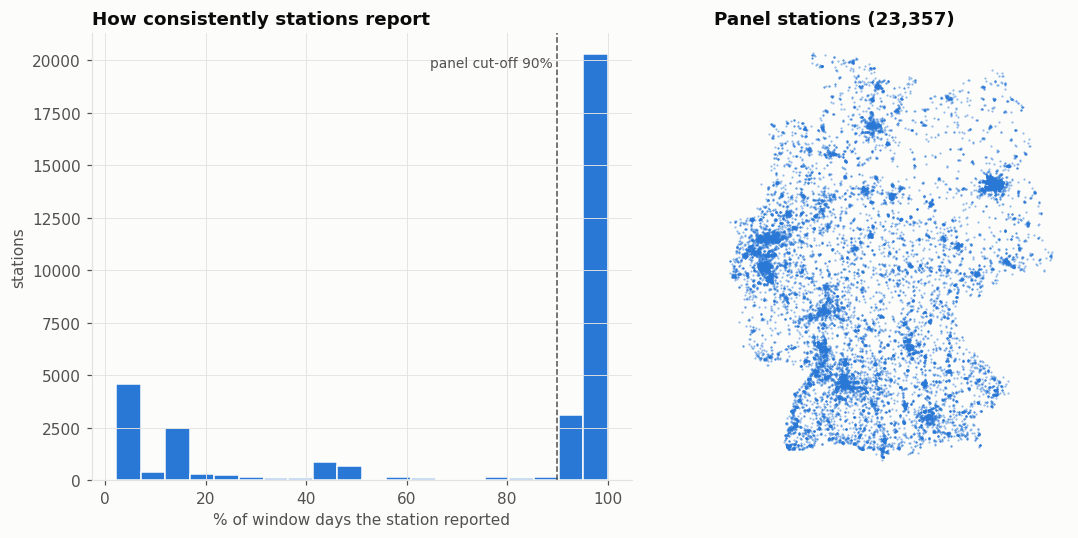

,panel stations
operator_name,
ENBW,2363
ChargePoint,1973
Ubitricity,1202
Lidl,875
solid GmbH,764
Berliner Stadtwerke GmbH,730
TankE GmbH,639
Shell Recharge,553
TotalEnergies,536


In [10]:
start, end = model_window["start"], model_window["end"]
excluded = set(model_window["excluded_days"])
window_files = [p for p in FILES
                if start <= str(day_of(p).date()) <= end and str(day_of(p).date()) not in excluded]
per_day = []
for path in window_files:
    df = pd.read_parquet(path, columns=["station_id", *LIVE])
    df["live"] = df[LIVE].sum(axis=1)
    per_day.append(df.groupby("station_id")["live"].max().rename("max_live").reset_index())
both = pd.concat(per_day, ignore_index=True)
presence = both.groupby("station_id").agg(days_present=("station_id", "size"),
                                          max_live_points=("max_live", "max")).reset_index()
usable_days = model_window["fit_days"]
presence["coverage"] = presence["days_present"] / usable_days
panel_ids = presence.loc[(presence["coverage"] >= 0.9) & (presence["max_live_points"] > 0), "station_id"]

stations = pd.read_parquet(PROCESSED / "stations.parquet")
panel = stations[stations["station_id"].isin(panel_ids)].copy()
panel.to_parquet(PROCESSED / "station_panel.parquet", index=False)

if presence.empty:
    raise ValueError("No status data inside the modelling window. Check data/processed/status/.")
print(f"{len(presence):,} stations appear in the window; {len(panel):,} ({len(panel) / len(presence):.0%}) "
      f"report on ≥90% of the {usable_days} usable days and form the panel.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1, 1.1]})
ax1.hist(presence["coverage"] * 100, bins=20, color=SERIES[0], edgecolor=SURFACE)
ax1.axvline(90, color=INK_2, lw=1, ls="--")
ax1.text(89, ax1.get_ylim()[1] * 0.95, "panel cut-off 90%", ha="right", va="top", fontsize=9, color=INK_2)
ax1.set_xlabel("% of window days the station reported")
ax1.set_ylabel("stations")
ax1.set_title("How consistently stations report")
ax2.scatter(panel["lon"], panel["lat"], s=2, color=SERIES[0], alpha=0.5, linewidths=0)
ax2.set_aspect(1.5)
ax2.set_title(f"Panel stations ({len(panel):,})")
ax2.set_xticks([]); ax2.set_yticks([]); ax2.grid(False)
for side in ("left", "bottom"):
    ax2.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

panel.groupby("operator_name").size().sort_values(ascending=False).head(10).rename("panel stations").to_frame()

## 7 · Findings

The cell below writes the findings as sentences from the numbers above. Pick the three strongest for the README's findings section; they are your interview talking points.

In [11]:
first_wide = manifest.loc[manifest["stations"] >= MIN_STATIONS, "day"].min().date()
typical_minutes = manifest["minutes_between"].rolling(7, center=True, min_periods=4).median()
fastest, slowest = typical_minutes.min(), typical_minutes.max()
top_unknown = recent.sort_values("unknown_share").iloc[-1]
window_mean = daily[(daily["day"] >= start) & (daily["day"] <= end)]
high_unknown = daily[daily["share_unknown"] > MAX_UNKNOWN]
peak = daily.loc[daily["share_unknown"].idxmax()]

findings = [
    f"Coverage grew from {manifest['stations'].iloc[0]:,} to {manifest['stations'].iloc[-1]:,} stations; "
    f"Germany-wide coverage (≥{MIN_STATIONS:,}) starts on {first_wide}.",
    f"Capture frequency is not constant: typically from one record every {fastest:.0f} minutes to one every "
    f"{slowest / 60:.1f} hours, so all models resample to a fixed hourly grid.",
    f"Live status was unreliable early on: 'unknown' peaked at {peak['share_unknown']:.0%} of charge points "
    f"on {peak['day'].date()}, and {len(high_unknown)} days exceed {MAX_UNKNOWN:.0%} unknown, so they are "
    f"excluded from modelling even where coverage was good.",
    f"The modelling window is {start} to {end}: {model_window['fit_days']} usable days "
    f"({len(model_window['excluded_days'])} partial days excluded).",
    f"A fixed panel of {len(panel):,} stations reports on ≥90% of those days; using it stops coverage "
    f"changes from looking like demand changes.",
    f"In the window, {window_mean['share_out_of_service'].mean():.1%} of live charge points were out of service "
    f"and {window_mean['share_unknown'].mean():.1%} unknown on an average day.",
    f"'{top_unknown['source']}' reports the most unknown status ({top_unknown['unknown_share']:.0%} of readings, "
    f"last 7 days), so its outages need a stricter alert rule.",
]
for i, f in enumerate(findings, 1):
    print(f"{i}. {f}")

1. Coverage grew from 699 to 35,980 stations; Germany-wide coverage (≥20,000) starts on 2026-05-19.
2. Capture frequency is not constant: typically from one record every 5 minutes to one every 2.5 hours, so all models resample to a fixed hourly grid.
3. Live status was unreliable early on: 'unknown' peaked at 86% of charge points on 2026-05-19, and 93 days exceed 15% unknown, so they are excluded from modelling even where coverage was good.
4. The modelling window is 2026-06-30 to 2026-08-14: 46 usable days (0 partial days excluded).
5. A fixed panel of 23,357 stations reports on ≥90% of those days; using it stops coverage changes from looking like demand changes.
6. In the window, 7.9% of live charge points were out of service and 3.1% unknown on an average day.
7. 'eaaze_pbw' reports the most unknown status (5% of readings, last 7 days), so its outages need a stricter alert rule.
